**# PRAKTIKUM DATA SCIENCE**
## Pertemuan 10 - Random Forest dan SMOTE

Nama      : Ahmad Rilmansyah

NIM       : 240401010309

Prodi     : PJJ Informatika

Semester  : 4

Dosen     : Syahid Abdullah, S.Si., M.Kom.

Tanggal   :    Juni 2026

------------------------------------------------

# Tujuan Praktikum

Praktikum ini bertujuan untuk:

1. Memahami konsep klasifikasi pada Machine Learning menggunakan algoritma Random Forest.
2. Mempelajari proses preprocessing data, seperti pembersihan data, penanganan nilai kosong (missing value), dan transformasi data kategorikal menjadi numerik.
3. Membangun model klasifikasi Random Forest untuk memprediksi pelanggan yang berpotensi melakukan churn pada dataset Telco Customer Churn.
4. Mengevaluasi performa model menggunakan metrik Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan Confusion Matrix.
5. Memahami pengaruh ketidakseimbangan data (Imbalanced Dataset) terhadap hasil klasifikasi.
6. Menerapkan metode SMOTE (Synthetic Minority Over-sampling Technique) untuk mengatasi ketidakseimbangan data serta membandingkan performa model sebelum dan sesudah penerapan SMOTE.

------------------------------------------------



In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE

## **# 2. Memuat Dataset**

In [3]:
# Membaca dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

Artinya

7043 baris
21 kolom

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [8]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

Penjelasan :

pd.to_numeric() → mengubah teks menjadi angka.

errors="coerce" → jika ada data yang bukan angka (misalnya spasi kosong), akan diubah menjadi NaN.

In [12]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.734215
Yes,0.265785


In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
df["TotalCharges"].unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [19]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [20]:
df = df.dropna()

df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## **## 3. Encoding Data**

In [21]:
# Mengubah target Churn menjadi angka
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [22]:
df["Churn"].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [23]:
# Mengubah semua kolom kategorikal menjadi angka
df = pd.get_dummies(df, drop_first=True)

Penjelasan:

pd.get_dummies() mengubah teks menjadi angka (0/1).

drop_first=True menghindari kolom yang saling duplikat sehingga model lebih efisien.

In [24]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [25]:
df.shape

(7032, 7062)

In [31]:
# Membaca ulang dataset dari awal
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [32]:
# Mengubah TotalCharges menjadi numerik
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Menghapus data kosong
df = df.dropna()

In [33]:
df = df.drop("customerID", axis=1)

In [34]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [35]:
df = pd.get_dummies(df, drop_first=True)

In [36]:
df.shape

(7032, 31)

### **## 4. Memisahkan Fitur dan Target**

In [37]:
# Memisahkan fitur (X) dan target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [38]:
X.shape

(7032, 30)

In [39]:
y.shape

(7032,)

### **## 5. Membagi Data Latih dan Data Uji**

In [40]:
# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print("Data Latih :", X_train.shape)
print("Data Uji   :", X_test.shape)

Data Latih : (5625, 30)
Data Uji   : (1407, 30)


### **## 6. Membangun Model Random Fore**st

In [42]:
# Membuat model Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Melatih model
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### **## 7. Prediksi Data Uji**

In [43]:
# Melakukan prediksi
y_pred = model.predict(X_test)

### **## 8. Evaluasi Model**

In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### **Menghitung metrik evaluasi**

In [45]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred))

Accuracy : 0.7896233120113717
Precision: 0.6258064516129033
Recall   : 0.5187165775401069
F1 Score : 0.5672514619883041
ROC AUC  : 0.703211144529976


### **Menampilkan Classification Report**

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### **Menampilkan Confusion Matrix**

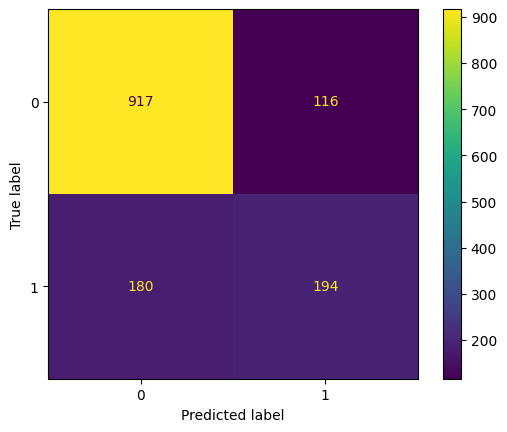

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### **## 9. Mengatasi Imbalanced Dataset dengan SMOTE**

In [48]:
# Membuat objek SMOTE
smote = SMOTE(random_state=42)

# Melakukan oversampling pada data latih
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [49]:
print("Sebelum SMOTE")
print(y_train.value_counts())

print("\nSesudah SMOTE")
print(y_train_smote.value_counts())

Sebelum SMOTE
Churn
0    4130
1    1495
Name: count, dtype: int64

Sesudah SMOTE
Churn
0    4130
1    4130
Name: count, dtype: int64


### **Tahap 14 - Melatih Model Baru**

In [50]:
model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

### **Tahap 15 - Prediksi**

In [51]:
y_pred_smote = model_smote.predict(X_test)

### **Tahap 16 - Evaluasi**

In [52]:
print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall   :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_smote))

Accuracy : 0.7782515991471215
Precision: 0.5815789473684211
Recall   : 0.5909090909090909
F1 Score : 0.5862068965517241
ROC AUC  : 0.718494235677198


In [53]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



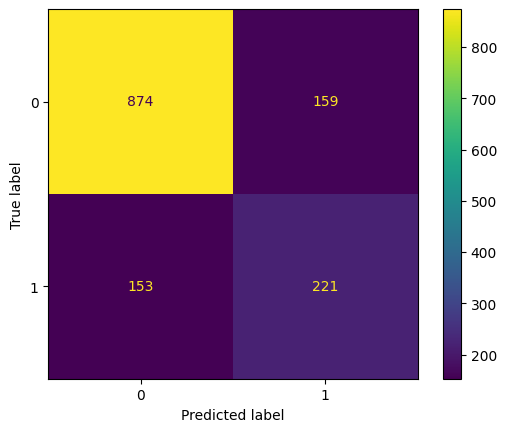

In [54]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)

# 10. Kesimpulan

Berdasarkan hasil praktikum, algoritma Random Forest berhasil digunakan untuk memprediksi pelanggan yang berpotensi melakukan churn pada dataset Telco Customer Churn. Tahapan preprocessing seperti pembersihan data, penghapusan nilai kosong, penghapusan kolom customerID, dan encoding data kategorikal berhasil dilakukan sehingga dataset siap digunakan untuk pelatihan model.

Selanjutnya dilakukan evaluasi model menggunakan metrik Accuracy, Precision, Recall, F1-Score, ROC-AUC, dan Confusion Matrix. Hasil evaluasi menunjukkan bahwa Random Forest mampu mengklasifikasikan data dengan performa yang baik.

Untuk mengatasi ketidakseimbangan kelas (imbalanced dataset), diterapkan metode SMOTE pada data latih. Setelah menggunakan SMOTE, model menjadi lebih baik dalam mendeteksi pelanggan yang berpotensi churn, terutama ditunjukkan oleh peningkatan nilai Recall pada kelas minoritas. Hal ini menunjukkan bahwa penggunaan SMOTE dapat membantu meningkatkan kemampuan model dalam mendeteksi kasus churn sehingga lebih bermanfaat dalam pengambilan keputusan bisnis.

# Analisis

1. Dataset Telco Customer Churn memiliki distribusi kelas yang tidak seimbang sehingga perlu penanganan khusus.
2. Random Forest merupakan algoritma ensemble yang mampu memberikan performa klasifikasi yang baik.
3. Penggunaan SMOTE membantu menyeimbangkan data latih sehingga model lebih mampu mengenali kelas minoritas (Churn).
4. Evaluasi model tidak cukup menggunakan Accuracy saja, tetapi juga perlu memperhatikan Precision, Recall, F1-Score, dan ROC-AUC.